In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import os
import pickle

sns.set_style("darkgrid")

colors = ["#6C5CE7", "#00B894", "#E17055", "#0984E3", "#FD79A8"]
sns.set_palette(colors)

In [7]:
df = pd.read_csv(r'C:\Users\PC\Downloads\dataset.csv')
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


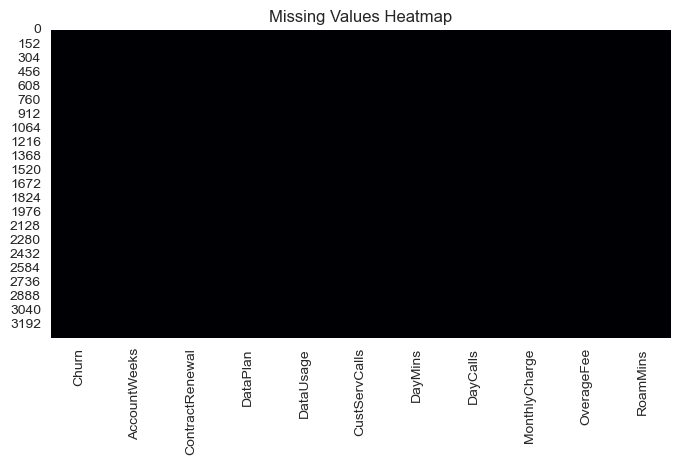

In [9]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap="magma")
plt.title("Missing Values Heatmap")
plt.show()

df = df.dropna()

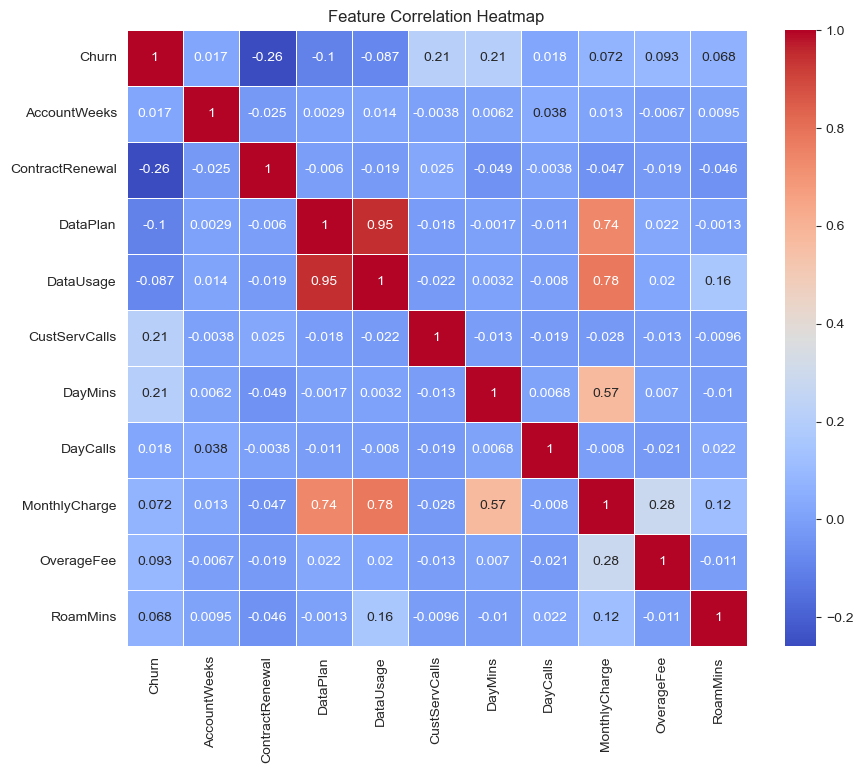

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

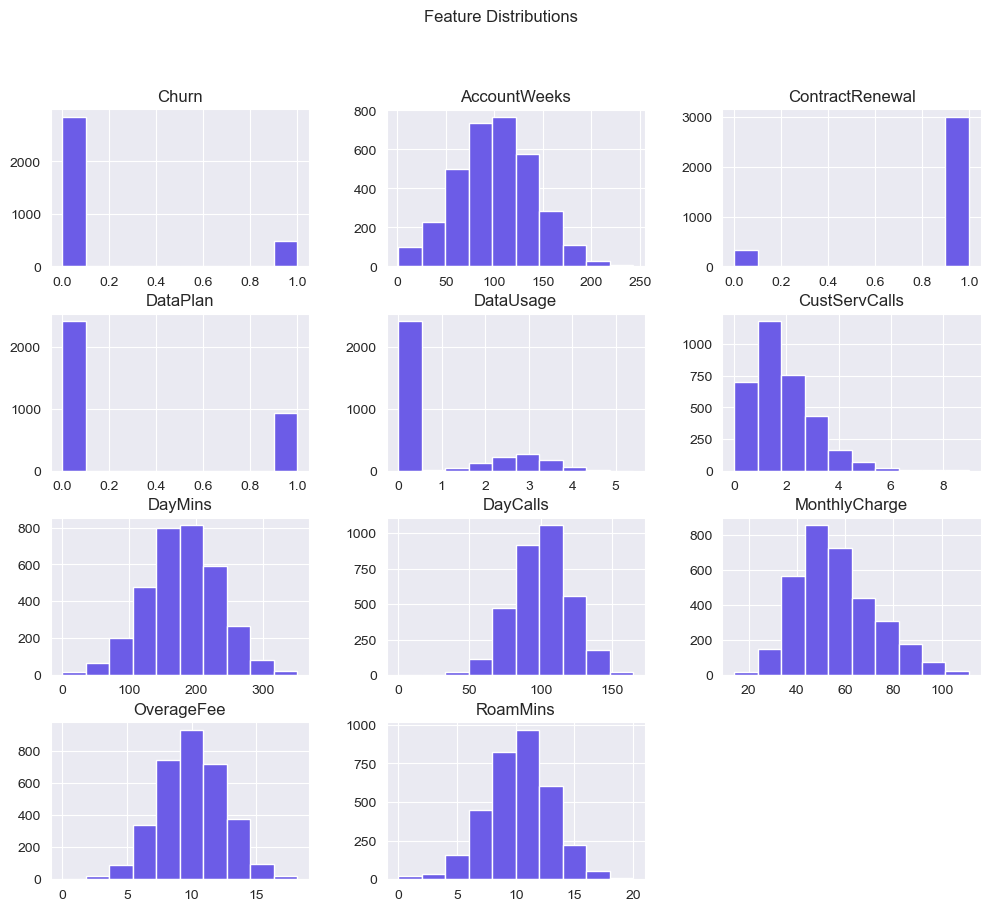

In [11]:
df.hist(figsize=(12,10), color="#6C5CE7")
plt.suptitle("Feature Distributions")
plt.show()

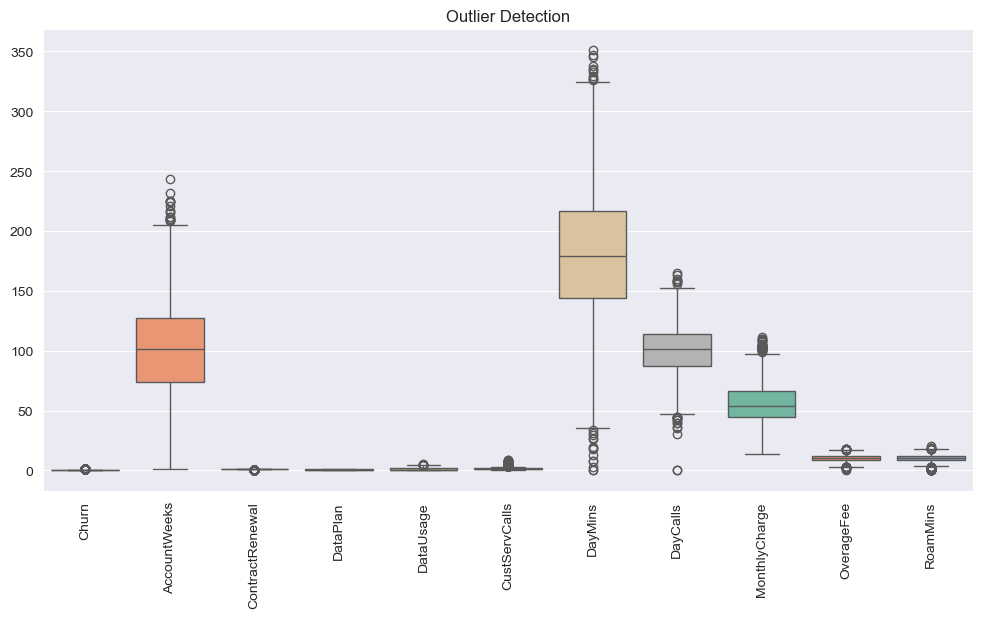

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, palette="Set2")
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [14]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 5.74168979910045
R2: 0.2524369663073186


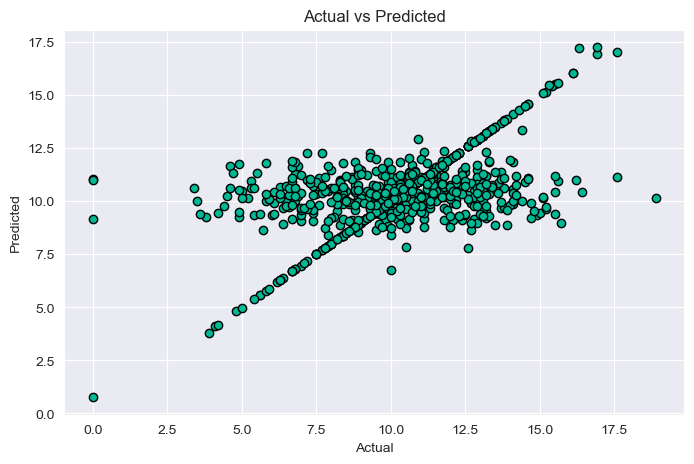

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color="#00B894", edgecolors="black")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

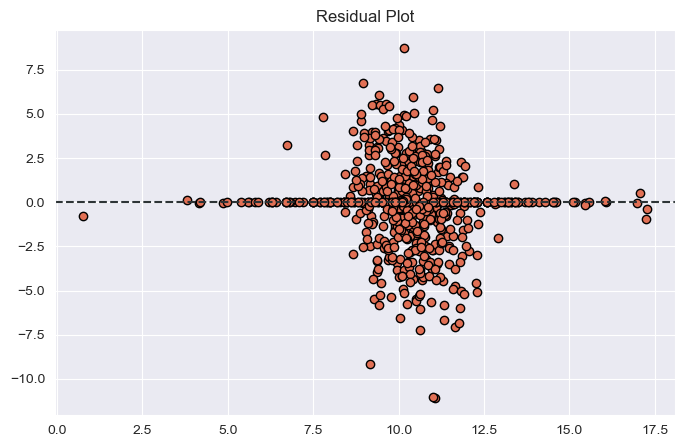

In [20]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, color="#E17055", edgecolors="black")
plt.axhline(0, color="#2d3436", linestyle='--')
plt.title("Residual Plot")
plt.show()

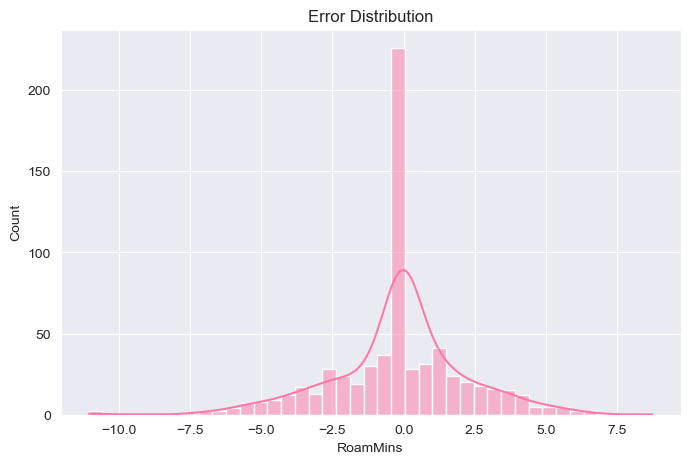

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True, color="#FD79A8")
plt.title("Error Distribution")
plt.show()

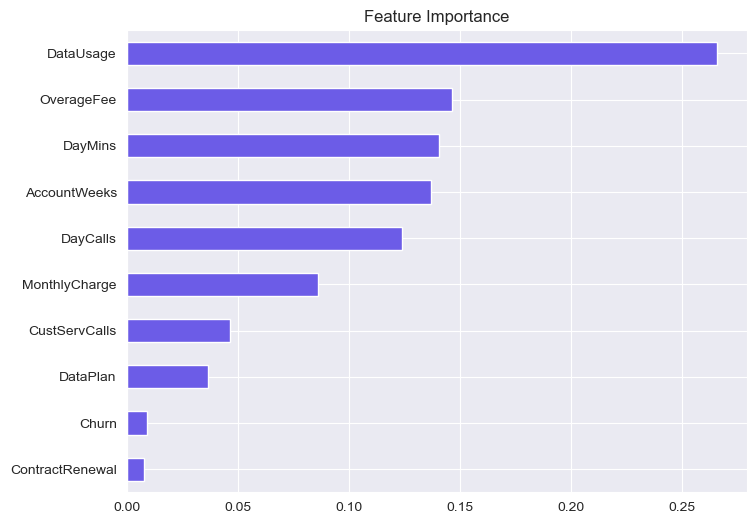

In [22]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns)

plt.figure(figsize=(8,6))
feat_imp.sort_values().plot(kind='barh', color="#6C5CE7")
plt.title("Feature Importance")
plt.show()

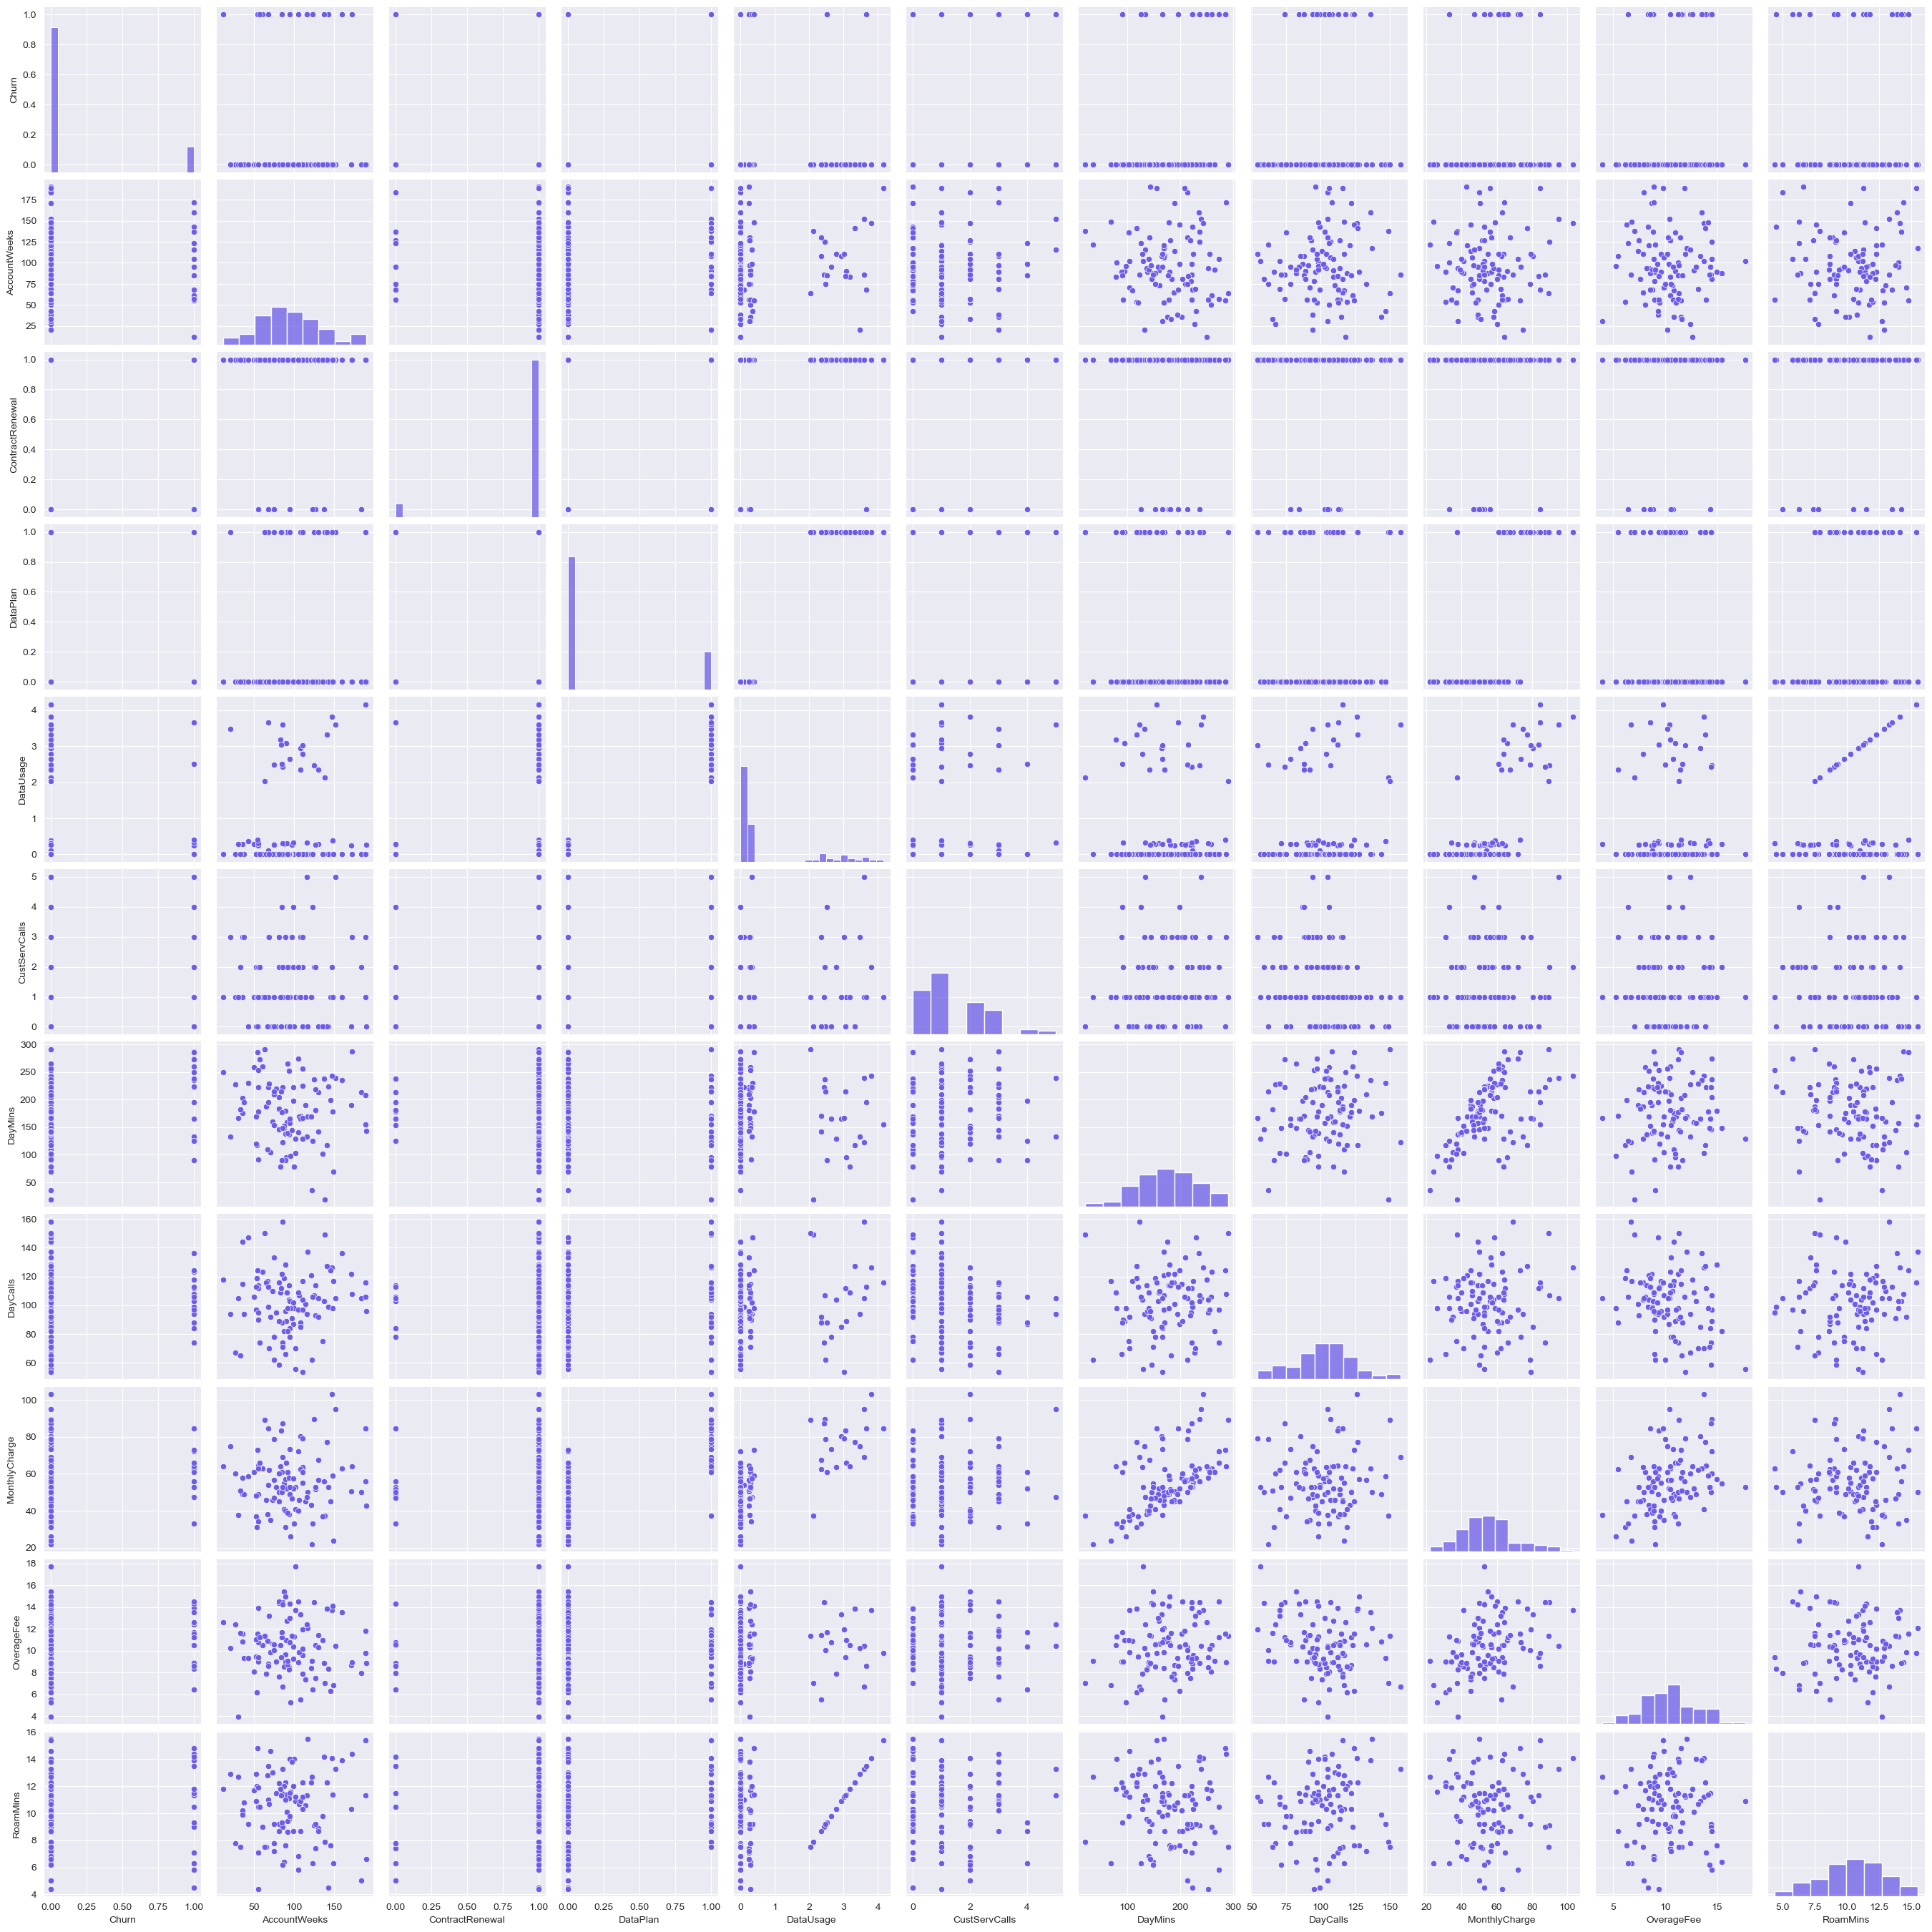

In [27]:
sns.pairplot(df.sample(100))
plt.show()

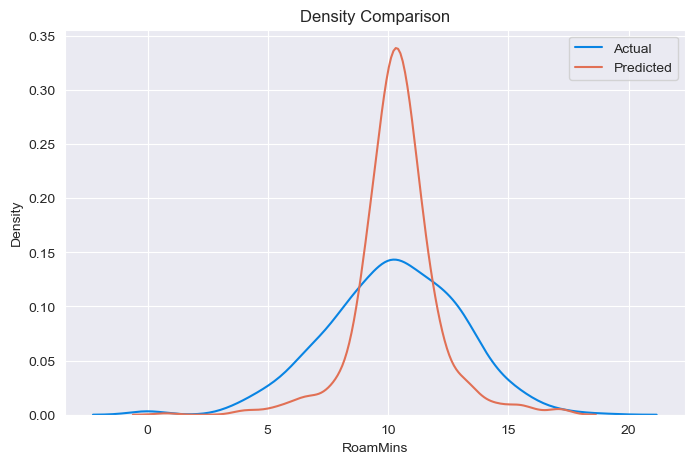

In [24]:
plt.figure(figsize=(8,5))
sns.kdeplot(y_test, label="Actual", color="#0984E3")
sns.kdeplot(y_pred, label="Predicted", color="#E17055")
plt.legend()
plt.title("Density Comparison")
plt.show()

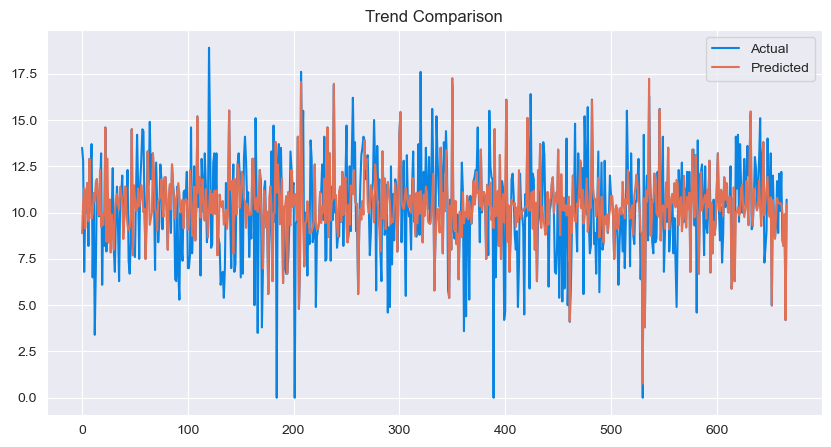

In [28]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual", color="#0984E3")
plt.plot(y_pred, label="Predicted", color="#E17055")
plt.legend()
plt.title("Trend Comparison")
plt.show()

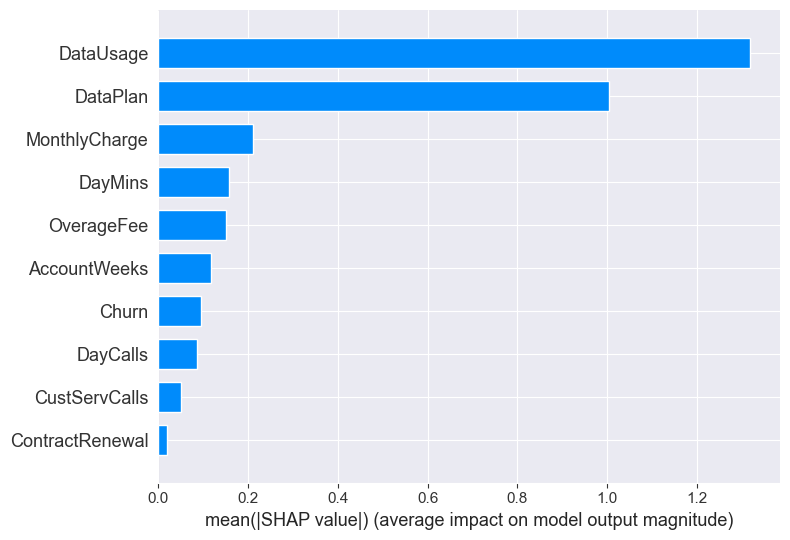

In [29]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")

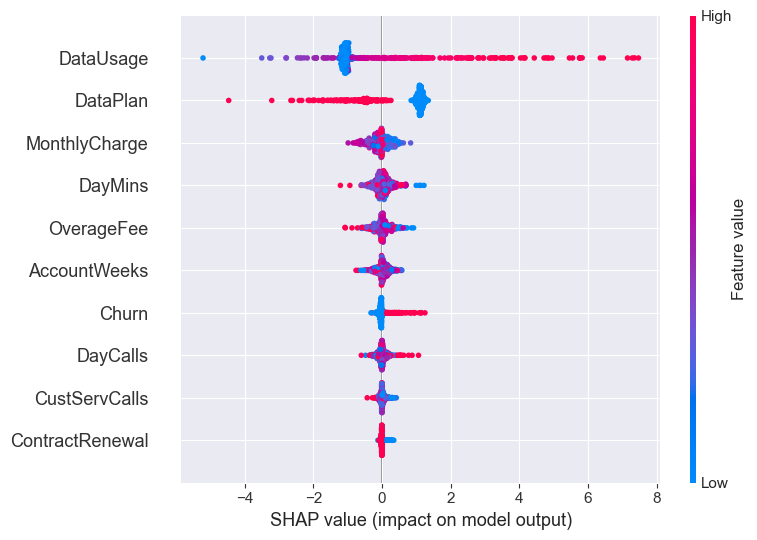

In [30]:
shap.summary_plot(shap_values, X_test)

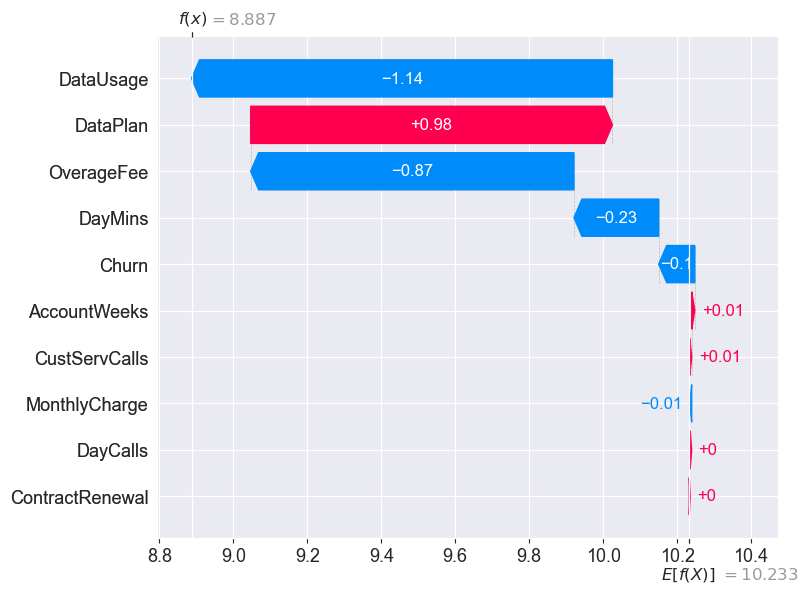

In [35]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[0],   # FIX HERE
    shap_values[0],                # first sample
    feature_names=X_test.columns
)

In [36]:
os.makedirs('outputs', exist_ok=True)

with open('outputs/model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [37]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.to_csv('outputs/predictions.csv', index=False)

In [40]:
import os
os.makedirs('outputs', exist_ok=True)

# Save trained model
import pickle
with open('outputs/final_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save predictions
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.to_csv('outputs/predictions.csv', index=False)

# Final summary
from sklearn.metrics import mean_squared_error, r2_score

print("========== FINAL MODEL SUMMARY ==========")
print("Model Used: Random Forest Regressor")
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

print("\nOutputs saved in 'outputs/' folder:")
print("- final_model.pkl")
print("- predictions.csv")

========== FINAL MODEL SUMMARY ==========
Model Used: Random Forest Regressor
R2 Score: 0.2524369663073186
MSE: 5.74168979910045

Outputs saved in 'outputs/' folder:
- final_model.pkl
- predictions.csv
